# Phase 3: Xử lý Mất Cân Bằng Dữ Liệu (Class Imbalance Handling)
## CICIoT2023 Network Intrusion Detection
### Đề tài Tốt nghiệp: Hệ thống phát hiện tấn công mạng IoT dựa trên XAI

---

### 🎯 Mục tiêu & Đóng góp Phương pháp luận của Phase 3
1. **Phân tích Định lượng (Quantitative Imbalance Analysis)**:
   - Đo lường mức độ mất cân bằng qua **Imbalance Ratio (IR)** và **Shannon Entropy Chuẩn hóa**.
   - Phân tầng 4 cấp độ nghiêm trọng: Majority ($\ge 5\%$), Medium ($1\%-5\%$), Minority ($0.1\%-1\%$), Extreme ($<0.1\%$).
2. **Cơ chế Phòng thủ Tỷ lệ Bảo toàn Lớp Hiếm (Proportionally Scaled Preservation)**:
   - Ngưỡng bảo toàn được điều chỉnh theo tỷ lệ subsampling: $N_c \times \text{ratio} < \text{min\_keep}$.
   - Đảm bảo các lớp cực hiếm (như `Uploading_Attack`, `Malware`, `Web`) giữ lại **100% mẫu thật**, tránh nội suy hàng nghìn mẫu giả từ vài mẫu thật.
   - Cơ chế **Adaptive Fallback**: Tự động dùng ROS nâng số mẫu lên $\ge k+2$ trước khi chạy SMOTE, chống lỗi crash $k$-NN.
3. **Phương pháp Paper-Aligned (SMOTE + Tomek Links - `SMOTETomek`)**:
   - **SMOTE**: Tạo mẫu nội suy nhân tạo thay vì sao chép ngẫu nhiên (tránh overfitting).
   - **Tomek Links**: Loại bỏ các cặp điểm nhiễu biên (borderline noise pairs), làm sắc nét ranh giới phân lớp.
   - **Two-Stage Scalable Hybrid**: Tỉa bớt lớp đa số khổng lồ $\rightarrow$ SMOTE lớp thiểu số $\rightarrow$ Tomek Links làm sạch ranh giới.
4. **Học Nhạy Cảm Chi Phí (Cost-Sensitive Learning - Class Weights)**:
   - Lưu trữ song song cả **Trọng số Gốc (Raw)** và **Trọng số Làm mượt (Smoothed)** phục vụ nghiên cứu thực nghiệm bóc tách (Ablation Study).
5. **Trực quan hóa Không gian Quyết định (Decision Space)**:
   - PCA 2D scatter plot kiểm chứng hiệu quả tách biên rõ rệt.

## Cấu hình Môi trường Google Colab & Điều hướng Lưu trữ trực tiếp trên Drive
> 🎯 **Lưu trữ trực tiếp**: Tự động mount Google Drive và chuyển working directory về . Mọi file (, , ) sinh ra sẽ nằm an toàn trên Drive của bạn.

In [1]:
# ==============================================================================
# Cấu hình Môi trường Google Colab & Điều hướng Lưu trữ trực tiếp trên Drive
# ==============================================================================
import os
import sys

# Kiểm tra nếu đang chạy trên Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    
    # 🎯 ĐIỀU HƯỚNG WORKING DIRECTORY TRỰC TIẾP VÀO THƯ MỤC GOOGLE DRIVE
    DRIVE_DIR = "/content/drive/MyDrive/do_an"
    os.makedirs(DRIVE_DIR, exist_ok=True)
    os.chdir(DRIVE_DIR)
    
    # Tạo sẵn các thư mục con lưu trữ trực tiếp trên Google Drive
    os.makedirs("data", exist_ok=True)
    os.makedirs("models", exist_ok=True)
    os.makedirs("plots", exist_ok=True)
    
    print(f"🚀 [Google Colab] Đã chuyển working directory trực tiếp về: {os.getcwd()}")
    print("📁 Tất cả kết quả (data/, models/, plots/) sẽ được ghi TRỰC TIẾP lên Google Drive!")
else:
    os.makedirs("data", exist_ok=True)
    os.makedirs("models", exist_ok=True)
    os.makedirs("plots", exist_ok=True)
    print(f"💻 [Local] Đang chạy trên máy cục bộ. Working directory: {os.getcwd()}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 [Google Colab] Đã chuyển working directory trực tiếp về: /content/drive/MyDrive/do_an
📁 Tất cả kết quả (data/, models/, plots/) sẽ được ghi TRỰC TIẾP lên Google Drive!


In [2]:
# ==============================================================================
# Cell 1: Khởi tạo Môi trường & Nạp Dữ liệu Tiền xử lý (Phase 2)
# ==============================================================================
import os
import gc
import json
import time
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, RandomOverSampler
from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from imblearn.combine import SMOTETomek, SMOTEENN

warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

os.makedirs('plots', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Nạp dữ liệu từ Phase 2
print("Đang nạp dữ liệu từ Phase 2...")
for p in ['data/X_train.pkl', 'X_train.pkl']:
    if os.path.exists(p):
        X_train = joblib.load(p)
        print(f"  Đã nạp X_train: {X_train.shape[0]:,} dòng x {X_train.shape[1]} đặc trưng")
        break

for p in ['data/y_train.pkl', 'y_train.pkl']:
    if os.path.exists(p):
        y_train_dict = joblib.load(p)
        print(f"  Đã nạp y_train keys: {list(y_train_dict.keys())}")
        break

preprocessor = joblib.load('models/preprocessor.joblib')
label_mapping = preprocessor['label_mapping']
category_mapping = preprocessor['category_mapping']
reverse_label_map = {v: k for k, v in label_mapping.items()}
reverse_cat_map = {v: k for k, v in category_mapping.items()}
print("Nạp dữ liệu thành công!")

Đang nạp dữ liệu từ Phase 2...
  Đã nạp X_train: 4,114,778 dòng x 58 đặc trưng
  Đã nạp y_train keys: ['label_encoded', 'label_name', 'category_encoded', 'category_name', 'is_attack']
Nạp dữ liệu thành công!


## Task 3.1: Phân tích Định lượng Độ Mất Cân Bằng (Imbalance Analysis)
- **Imbalance Ratio (IR)**: $$IR = \frac{\max_i (N_i)}{\min_i (N_i)}$$
- **Shannon Entropy Chuẩn hóa**: $$H(Y) = -\sum_{i=1}^{C} p_i \log_2(p_i), \quad \text{Entropy Ratio} = \frac{H(Y)}{\log_2(C)} \in [0, 1]$$

In [3]:
# ==============================================================================
# Cell 2: Phân tích Định lượng 34 Lớp & 9 Nhóm Tấn công
# ==============================================================================
y_train_encoded = y_train_dict['label_encoded']
y_train_names = y_train_dict['label_name']
y_cat_encoded = y_train_dict['category_encoded']
y_cat_names = y_train_dict['category_name']
y_binary = y_train_dict['is_attack']

total_samples = len(y_train_names)
label_counts = pd.Series(y_train_names).value_counts()
label_pct = (label_counts / total_samples) * 100

cat_counts = pd.Series(y_cat_names).value_counts()
cat_pct = (cat_counts / total_samples) * 100

# IR
ir_fine = label_counts.max() / label_counts.min()
ir_cat = cat_counts.max() / cat_counts.min()

# Shannon Entropy
p_fine = label_counts.values / total_samples
ent_fine = -np.sum(p_fine * np.log2(p_fine + 1e-12)) / np.log2(len(label_counts))

p_cat = cat_counts.values / total_samples
ent_cat = -np.sum(p_cat * np.log2(p_cat + 1e-12)) / np.log2(len(cat_counts))

# Phân tầng 4 cấp độ nghiêm trọng
majority = label_pct[label_pct >= 5.0].index.tolist()
medium = label_pct[(label_pct >= 1.0) & (label_pct < 5.0)].index.tolist()
minority = label_pct[(label_pct >= 0.1) & (label_pct < 1.0)].index.tolist()
extreme = label_pct[label_pct < 0.1].index.tolist()

print(f"Tổng số mẫu Train:       {total_samples:,} flows")
print(f"Số lớp chi tiết:         {len(label_counts)} (33 Attacks + Benign) | Số nhóm: {len(cat_counts)} (8 Attack Groups + Benign)")
print(f"Imbalance Ratio (34):    {ir_fine:,.1f}:1 ({label_counts.idxmax()}={label_counts.max():,} vs {label_counts.idxmin()}={label_counts.min():,})")
print(f"Imbalance Ratio (Nhóm):  {ir_cat:,.1f}:1 ({cat_counts.idxmax()}={cat_counts.max():,} vs {cat_counts.idxmin()}={cat_counts.min():,})")
print(f"Shannon Entropy Ratio:   {ent_fine:.4f} (34 lớp) | {ent_cat:.4f} (Nhóm)")
print("-" * 70)
print(f"[1] Majority (>= 5%):     {len(majority):2d} lớp ({sum(label_pct[c] for c in majority):.2f}% lưu lượng)")
print(f"[2] Medium (1% - 5%):     {len(medium):2d} lớp ({sum(label_pct[c] for c in medium):.2f}% lưu lượng)")
print(f"[3] Minority (0.1% - 1%): {len(minority):2d} lớp ({sum(label_pct[c] for c in minority):.2f}% lưu lượng)")
print(f"[4] Extreme (< 0.1%):     {len(extreme):2d} lớp ({sum(label_pct[c] for c in extreme):.2f}% lưu lượng)")

Tổng số mẫu Train:       4,114,778 flows
Số lớp chi tiết:         34 (33 Attacks + Benign) | Số nhóm: 9 (8 Attack Groups + Benign)
Imbalance Ratio (34):    4,475.0:1 (DDoS-UDP_Flood=622,030 vs Uploading_Attack=139)
Imbalance Ratio (Nhóm):  7,130.8:1 (DDoS=2,766,731 vs Malware=388)
Shannon Entropy Ratio:   0.7664 (34 lớp) | 0.4518 (Nhóm)
----------------------------------------------------------------------
[1] Majority (>= 5%):     10 lớp (84.53% lưu lượng)
[2] Medium (1% - 5%):      5 lớp (11.07% lưu lượng)
[3] Minority (0.1% - 1%):  9 lớp (4.14% lưu lượng)
[4] Extreme (< 0.1%):     10 lớp (0.25% lưu lượng)


## Trực quan hóa Mức độ Mất Cân Bằng (Plot 06)

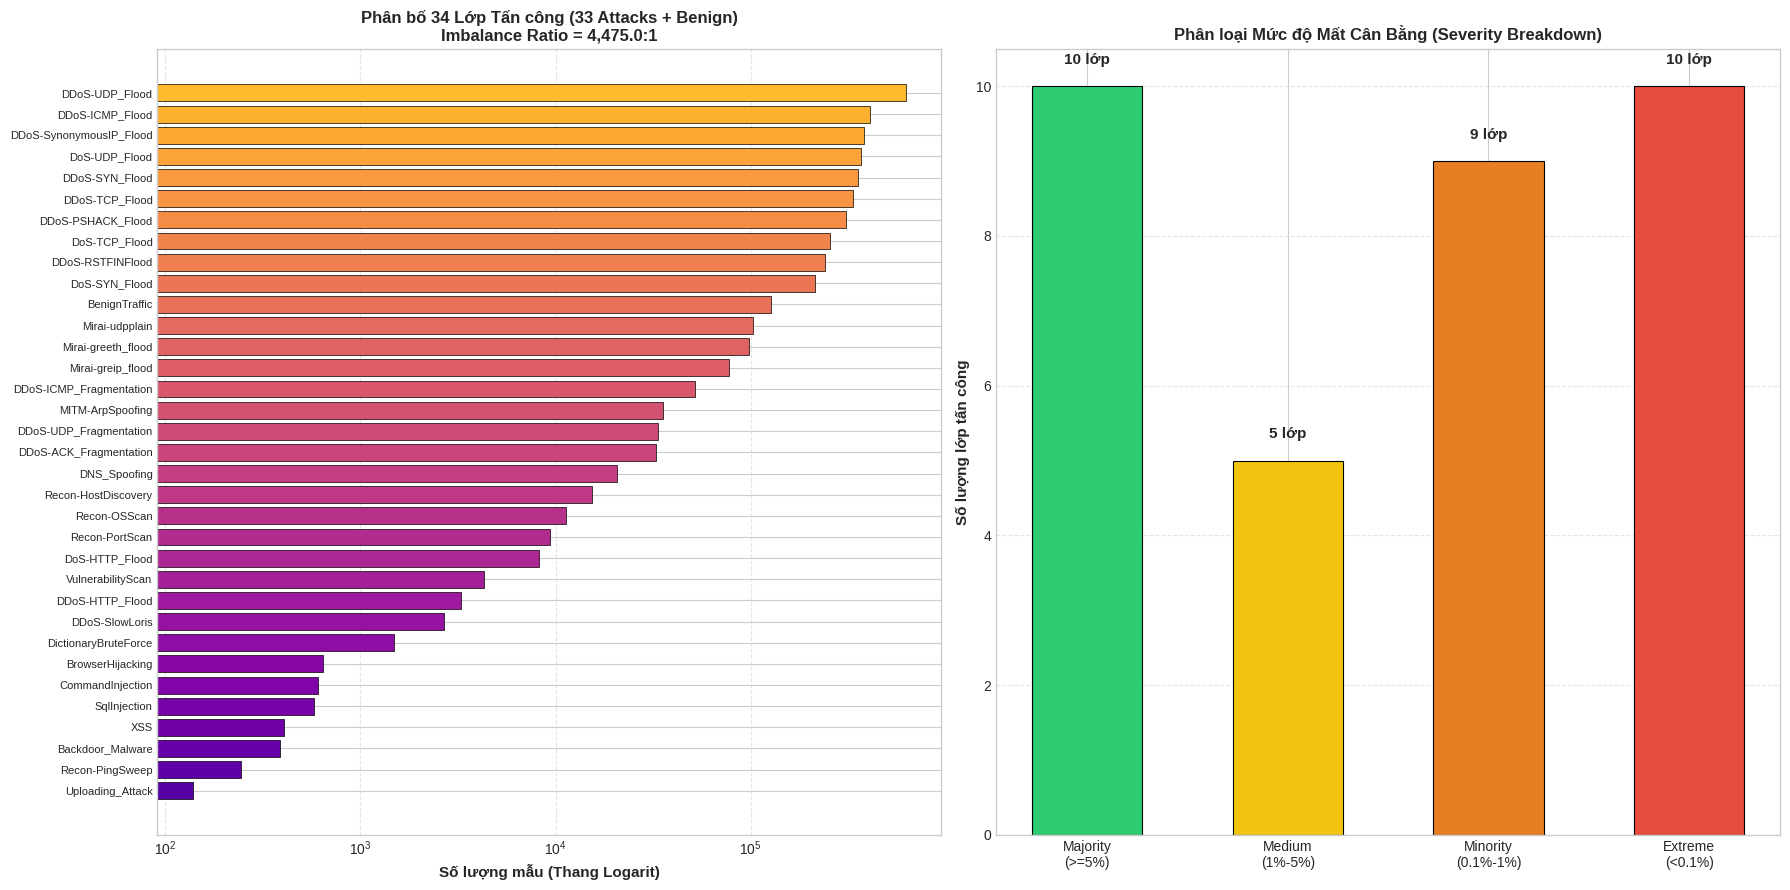

In [4]:
# ==============================================================================
# Cell 3: Vẽ Biểu đồ Phân tích Mất Cân Bằng (Plot 06)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

ax1 = axes[0]
colors_bar = plt.cm.plasma(np.linspace(0.15, 0.85, len(label_counts)))[::-1]
ax1.barh(range(len(label_counts)), label_counts.values, color=colors_bar, edgecolor='black', linewidth=0.5)
ax1.set_yticks(range(len(label_counts)))
ax1.set_yticklabels(label_counts.index, fontsize=8)
ax1.set_xscale('log')
ax1.set_xlabel('Số lượng mẫu (Thang Logarit)', fontsize=11, fontweight='bold')
ax1.set_title(f'Phân bố 34 Lớp Tấn công (33 Attacks + Benign)\nImbalance Ratio = {ir_fine:,.1f}:1', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5, axis='x')
ax1.invert_yaxis()

ax2 = axes[1]
tier_labels = ['Majority\n(>=5%)', 'Medium\n(1%-5%)', 'Minority\n(0.1%-1%)', 'Extreme\n(<0.1%)']
tier_counts = [len(majority), len(medium), len(minority), len(extreme)]
tier_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax2.bar(tier_labels, tier_counts, color=tier_colors, edgecolor='black', linewidth=0.8, width=0.55)
ax2.set_ylabel('Số lượng lớp tấn công', fontsize=11, fontweight='bold')
ax2.set_title('Phân loại Mức độ Mất Cân Bằng (Severity Breakdown)', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5, axis='y')
for bar, count in zip(bars, tier_counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{count} lớp", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/06_imbalance_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

## Task 3.2A: Chiến lược Học Nhạy Cảm Chi Phí (Cost-Sensitive Learning)
Lưu trữ song song cả **Trọng số Gốc (Raw)** và **Trọng số Làm mượt (Smoothed)** để phục vụ Ablation Study.
> ⚠️ **Cảnh báo Double-Correction**: Tuyệt đối không dùng `class_weight` khi đã huấn luyện trên tập đã resample (`X_train_balanced.pkl`).

In [5]:
# ==============================================================================
# Cell 4: Tính toán Class Weights (Lưu cả Raw và Smoothed)
# ==============================================================================
def apply_smoothing(w_dict, mode='none'):
    if mode == 'sqrt':
        return {k: round(float(np.sqrt(v)), 6) for k, v in w_dict.items()}
    elif mode == 'cap':
        return {k: round(float(min(v, 100.0)), 6) for k, v in w_dict.items()}
    return {k: round(float(v), 6) for k, v in w_dict.items()}

# 1. 34 Lớp chi tiết
unique_labels = np.unique(y_train_encoded)
cw_arr = compute_class_weight('balanced', classes=unique_labels, y=y_train_encoded)
raw_cw_encoded = dict(zip(unique_labels.tolist(), [round(float(w), 6) for w in cw_arr]))
raw_cw_named = {reverse_label_map[c]: raw_cw_encoded[c] for c in unique_labels}
cw_encoded = apply_smoothing(raw_cw_encoded, 'none')
cw_named = {reverse_label_map[c]: cw_encoded[c] for c in unique_labels}

# 2. Nhóm tấn công (Categories - 9 classes)
unique_cats = np.unique(y_cat_encoded)
cat_arr = compute_class_weight('balanced', classes=unique_cats, y=y_cat_encoded)
raw_cat_encoded = dict(zip(unique_cats.tolist(), [round(float(w), 6) for w in cat_arr]))
raw_cat_named = {reverse_cat_map[c]: raw_cat_encoded[c] for c in unique_cats}
cat_encoded = apply_smoothing(raw_cat_encoded, 'none')
cat_named = {reverse_cat_map[c]: cat_encoded[c] for c in unique_cats}

# 3. Nhị phân
unique_bin = np.unique(y_binary)
bin_arr = compute_class_weight('balanced', classes=unique_bin, y=y_binary)
bin_weights = dict(zip(unique_bin.tolist(), [round(float(w), 6) for w in bin_arr]))

print(f"Trọng số 34 lớp chi tiết: Max = {max(cw_named.items(), key=lambda x: x[1])}, Min = {min(cw_named.items(), key=lambda x: x[1])}")
print("\nTrọng số các nhóm tấn công (Categories - 9 groups):")
for k, v in sorted(cat_named.items(), key=lambda x: x[1], reverse=True):
    print(f"  {k:<15}: {v:8.4f}")
print(f"\nTrọng số nhị phân: Benign (0) = {bin_weights[0]:.4f} | Attack (1) = {bin_weights[1]:.4f}")

Trọng số 34 lớp chi tiết: Max = ('Uploading_Attack', 870.668218), Min = ('DDoS-UDP_Flood', 0.194561)

Trọng số các nhóm tấn công (Categories - 9 groups):
  Malware        : 1178.3442
  BruteForce     : 307.2564
  Web            : 192.0998
  Recon          :  11.2705
  Spoofing       :   8.1504
  Benign         :   3.6172
  Mirai          :   1.6464
  DoS            :   0.5423
  DDoS           :   0.1652

Trọng số nhị phân: Benign (0) = 16.2776 | Attack (1) = 0.5158


## Trực quan hóa Class Weights (Plot 07)

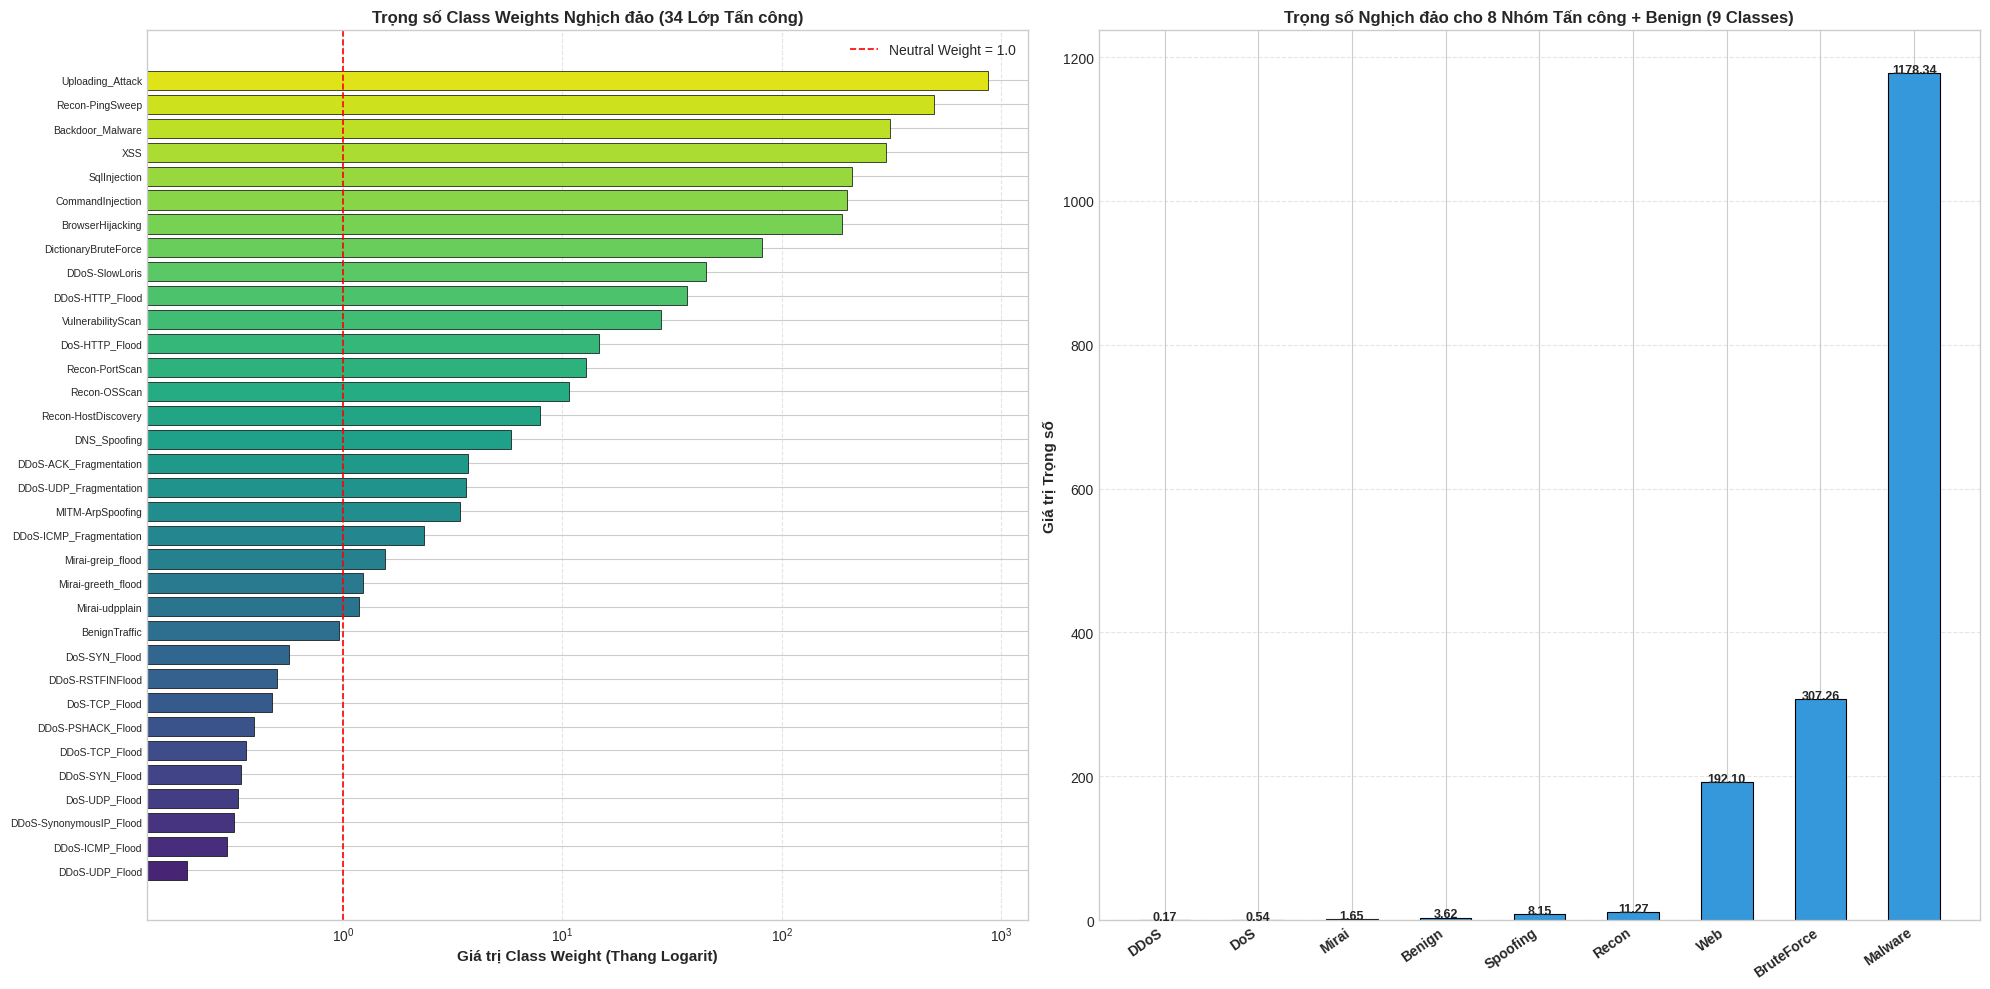

In [6]:
# ==============================================================================
# Cell 5: Vẽ Biểu đồ Class Weights (Plot 07)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

ax1 = axes[0]
sorted_cw = sorted(cw_named.items(), key=lambda x: x[1])
names_w = [x[0] for x in sorted_cw]
vals_w = [x[1] for x in sorted_cw]
colors_w = plt.cm.viridis(np.linspace(0.1, 0.95, len(vals_w)))
ax1.barh(range(len(names_w)), vals_w, color=colors_w, edgecolor='black', linewidth=0.5)
ax1.set_yticks(range(len(names_w)))
ax1.set_yticklabels(names_w, fontsize=7.5)
ax1.set_xscale('log')
ax1.set_xlabel('Giá trị Class Weight (Thang Logarit)', fontsize=11, fontweight='bold')
ax1.set_title('Trọng số Class Weights Nghịch đảo (34 Lớp Tấn công)', fontsize=12, fontweight='bold')
ax1.axvline(x=1.0, color='red', linestyle='--', linewidth=1.2, label='Neutral Weight = 1.0')
ax1.grid(True, linestyle='--', alpha=0.5, axis='x')
ax1.legend()

ax2 = axes[1]
sorted_cat = sorted(cat_named.items(), key=lambda x: x[1])
names_cat = [x[0] for x in sorted_cat]
vals_cat = [x[1] for x in sorted_cat]
bars_cat = ax2.bar(names_cat, vals_cat, color='#3498db', edgecolor='black', linewidth=0.8, width=0.55)
ax2.set_ylabel('Giá trị Trọng số', fontsize=11, fontweight='bold')
ax2.set_title('Trọng số Nghịch đảo cho 8 Nhóm Tấn công + Benign (9 Classes)', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(names_cat))) # Explicit ticks
ax2.set_xticklabels(names_cat, rotation=35, ha='right', fontsize=10, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5, axis='y')
for bar, val in zip(bars_cat, vals_cat):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             f"{val:.2f}", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/07_class_weights.png', dpi=200, bbox_inches='tight')
plt.show()

## Task 3.2B: Phương pháp Resampling Chuẩn Paper (SMOTE + Tomek Links)
Sử dụng công thức bảo toàn theo tỷ lệ: Mọi lớp có $N_c \times \text{ratio} < \text{min\_subsample\_keep}$ sẽ được bảo toàn **100% mẫu thật**!

In [7]:
# ==============================================================================
# Cell 6: Thực thi Two-Stage Scalable Resampling (SMOTE + Tomek Links)
# ==============================================================================
TARGET_TIER = 'label'      # 'label' (34 lớp chi tiết) hoặc 'category' (9 nhóm)
SAMPLE_SIZE = 100000       # Ngân sách lấy mẫu phân tầng ban đầu
MIN_SUBSAMPLE_KEEP = 100   # Ngưỡng kỳ vọng tối thiểu để bảo toàn 100% mẫu thật
TARGET_MAJORITY = 30000    # Pruning lớp đa số xuống tối đa 30,000 dòng
TARGET_MINORITY = 8000     # SMOTE lớp thiểu số lên 8,000 dòng
K_NEIGHBORS = 5
RANDOM_STATE = 42

target_data = y_train_encoded if TARGET_TIER == 'label' else y_cat_encoded
reverse_map = reverse_label_map if TARGET_TIER == 'label' else reverse_cat_map

print("=" * 75)
print(f"TASK 3.2B: RESAMPLING (SMOTE + TOMEK LINKS) - TẦNG: {TARGET_TIER.upper()}")
print("=" * 75)

# 1. Proportionally Scaled Guaranteed Minority Preservation
total_rows = len(target_data)
counts_full = pd.Series(target_data).value_counts()
ratio = SAMPLE_SIZE / total_rows
rare_classes = counts_full[(counts_full * ratio) < MIN_SUBSAMPLE_KEEP].index.tolist()

if rare_classes and SAMPLE_SIZE < total_rows:
    print(f"  [Bảo toàn lớp hiếm theo tỷ lệ] Giữ 100% mẫu cho {len(rare_classes)} lớp hiếm (kỳ vọng < {MIN_SUBSAMPLE_KEEP} mẫu)...")
    y_ser = pd.Series(target_data)
    rare_idx = y_ser[y_ser.isin(rare_classes)].index.values
    comm_idx = y_ser[~y_ser.isin(rare_classes)].index.values
    
    X_rare = X_train.iloc[rare_idx]
    y_rare = target_data[rare_idx]
    X_comm = X_train.iloc[comm_idx]
    y_comm = target_data[comm_idx]
    
    rem_budget = max(len(counts_full) * 20, SAMPLE_SIZE - len(y_rare))
    _, X_sub_c, _, y_sub_c = train_test_split(
        X_comm, y_comm, test_size=rem_budget,
        stratify=y_comm, random_state=RANDOM_STATE
    )
    X_sub = pd.concat([X_rare, X_sub_c], axis=0).reset_index(drop=True)
    y_sub = np.concatenate([y_rare, y_sub_c])
else:
    _, X_sub, _, y_sub = train_test_split(
        X_train, target_data, test_size=SAMPLE_SIZE,
        stratify=target_data, random_state=RANDOM_STATE
    )
    X_sub = pd.DataFrame(X_sub, columns=X_train.columns) if hasattr(X_train, 'columns') else pd.DataFrame(X_sub)
    y_sub = np.array(y_sub)

assert len(set(y_sub)) == len(set(target_data)), "Lỗi: Có lớp bị mất trong subsample!"
counts_init = pd.Series(y_sub).value_counts()
print(f"Tập mẫu ban đầu: {len(y_sub):,} dòng preserving {len(counts_init)} lớp hoàn hảo (min count = {counts_init.min():,}).")

# 2. Stage 1: Smart Majority Pruning
strat_under = {c: TARGET_MAJORITY for c, cnt in counts_init.items() if cnt > TARGET_MAJORITY}
if strat_under:
    print(f"  [Stage 1: Undersampling] Tỉa {len(strat_under)} lớp đa số xuống {TARGET_MAJORITY:,}...")
    rus = RandomUnderSampler(sampling_strategy=strat_under, random_state=RANDOM_STATE)
    X_work, y_work = rus.fit_resample(X_sub, y_sub)
else:
    X_work, y_work = X_sub.copy(), y_sub.copy()

# 3. Stage 2: SMOTE Synthesis với Adaptive ROS Fallback
counts_mid = pd.Series(y_work).value_counts()
strat_over = {c: TARGET_MINORITY for c, cnt in counts_mid.items() if cnt < TARGET_MINORITY}
if strat_over:
    ros_targets = {c: K_NEIGHBORS + 2 for c in strat_over if counts_mid[c] <= K_NEIGHBORS}
    if ros_targets:
        print(f"  [Adaptive ROS Fallback] Nhân bản {len(ros_targets)} lớp cực hiếm lên {K_NEIGHBORS+2} mẫu trước SMOTE...")
        ros = RandomOverSampler(sampling_strategy=ros_targets, random_state=RANDOM_STATE)
        X_work, y_work = ros.fit_resample(X_work, y_work)
    
    print(f"  [Stage 2: SMOTE Synthesis] Nội suy {len(strat_over)} lớp thiểu số lên {TARGET_MINORITY:,}...")
    smote = SMOTE(sampling_strategy=strat_over, k_neighbors=K_NEIGHBORS, random_state=RANDOM_STATE)
    X_work, y_work = smote.fit_resample(X_work, y_work)

# 4. Stage 3: Tomek Links Boundary Cleaning
print("  [Stage 3: Tomek Links] Đang loại bỏ các cặp điểm nhiễu biên (Borderline Pairs)...")
t0 = time.time()
tomek = TomekLinks(sampling_strategy='all', n_jobs=-1)
X_clean, y_clean = tomek.fit_resample(X_work, y_work)
print(f"  -> Hoàn tất Tomek Links trong {time.time() - t0:.2f} giây!")

counts_final = pd.Series(y_clean).value_counts()
print("-" * 75)
print(f"Số dòng biến thiên: {len(y_sub):,} -> {len(y_clean):,} dòng")
print(f"Imbalance Ratio:    {counts_init.max()/counts_init.min():,.1f}:1  ->  {counts_final.max()/counts_final.min():.2f}:1")

TASK 3.2B: RESAMPLING (SMOTE + TOMEK LINKS) - TẦNG: LABEL
  [Bảo toàn lớp hiếm theo tỷ lệ] Giữ 100% mẫu cho 10 lớp hiếm (kỳ vọng < 100 mẫu)...
Tập mẫu ban đầu: 100,000 dòng preserving 34 lớp hoàn hảo (min count = 94).
  [Stage 2: SMOTE Synthesis] Nội suy 31 lớp thiểu số lên 8,000...
  [Stage 3: Tomek Links] Đang loại bỏ các cặp điểm nhiễu biên (Borderline Pairs)...
  -> Hoàn tất Tomek Links trong 632.52 giây!
---------------------------------------------------------------------------
Số dòng biến thiên: 100,000 -> 267,062 dòng
Imbalance Ratio:    144.3:1  ->  1.88:1


## Trực quan hóa So sánh & Quyết định Biên (Plots 08 & 08b)

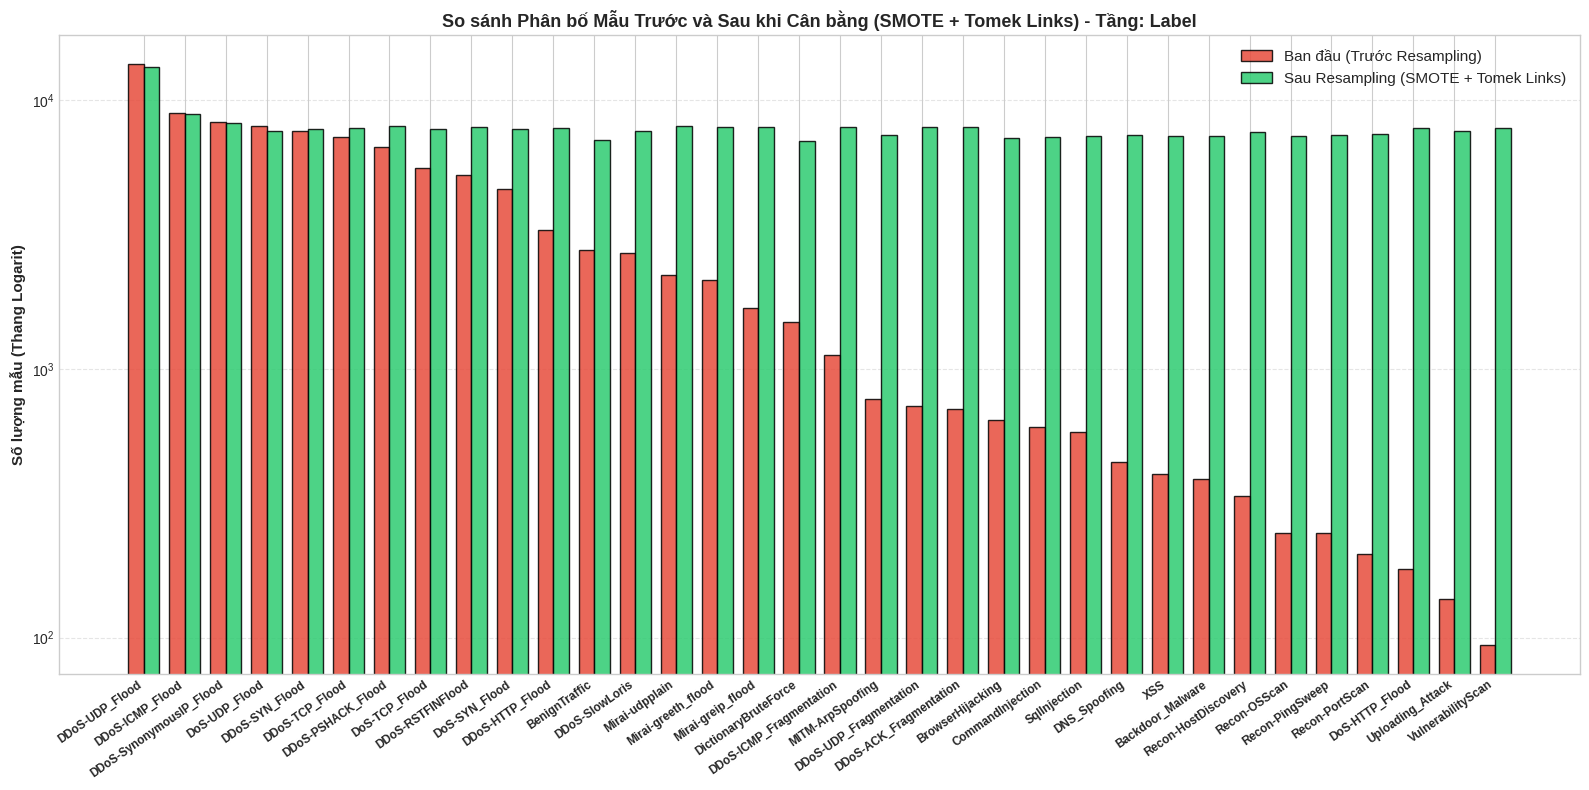

In [8]:
# ==============================================================================
# Cell 7: Vẽ Biểu đồ So sánh Trước và Sau Resampling (Plot 08)
# ==============================================================================
fig, ax = plt.subplots(figsize=(16, 8))
common_indices = counts_init.index
x_indices = np.arange(len(common_indices))
bar_width = 0.38

counts_b = [counts_init.get(k, 0) for k in common_indices]
counts_a = [counts_final.get(k, 0) for k in common_indices]
tick_labels = [reverse_map.get(k, str(k)) for k in common_indices]

ax.bar(x_indices - bar_width/2, counts_b, width=bar_width,
       label='Ban đầu (Trước Resampling)', color='#e74c3c', alpha=0.85, edgecolor='black')
ax.bar(x_indices + bar_width/2, counts_a, width=bar_width,
       label='Sau Resampling (SMOTE + Tomek Links)', color='#2ecc71', alpha=0.85, edgecolor='black')

ax.set_ylabel('Số lượng mẫu (Thang Logarit)', fontsize=11, fontweight='bold')
ax.set_yscale('log')
ax.set_title(f'So sánh Phân bố Mẫu Trước và Sau khi Cân bằng (SMOTE + Tomek Links) - Tầng: {TARGET_TIER.title()}',
             fontsize=13, fontweight='bold')
ax.set_xticks(x_indices)
ax.set_xticklabels(tick_labels, rotation=35, ha='right', fontsize=8.5 if len(tick_labels) > 15 else 10, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('plots/08_resampling_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

Đang giảm chiều PCA để trực quan hóa 2D không gian quyết định...


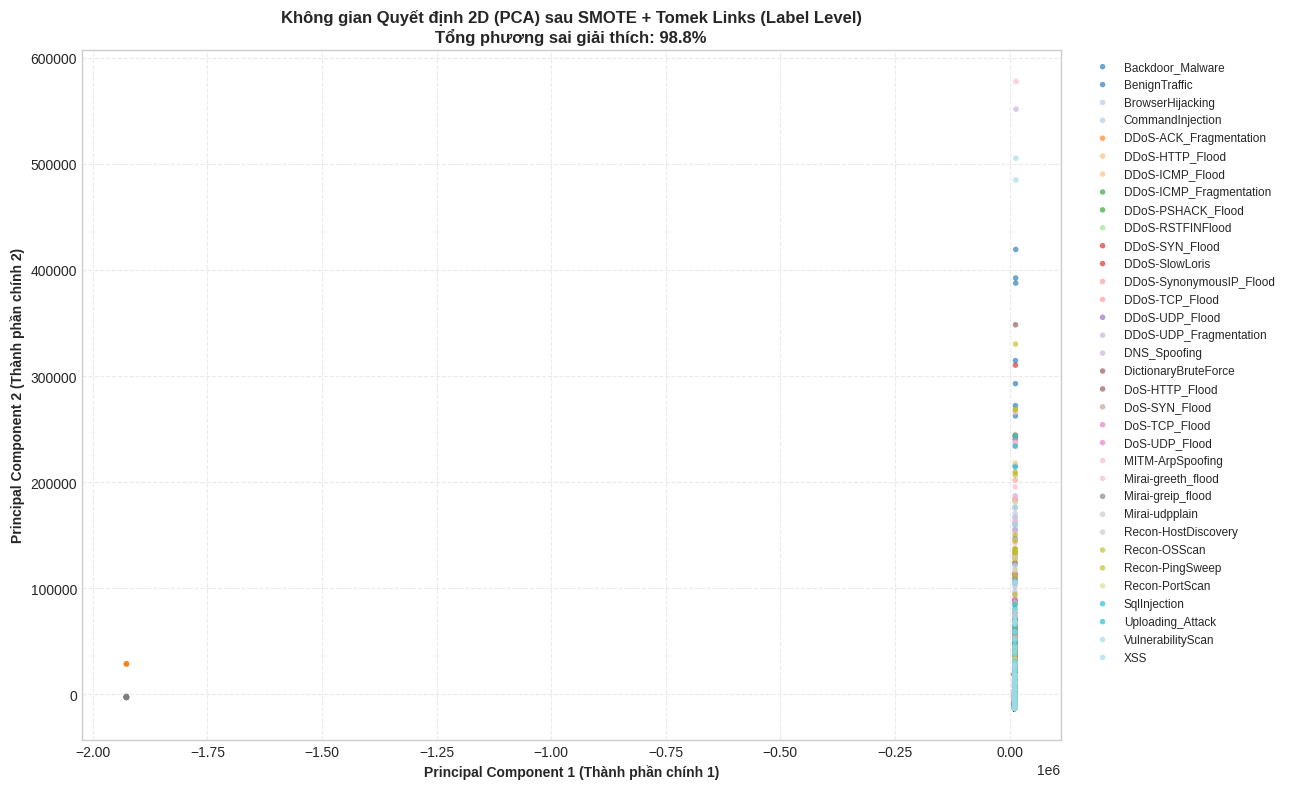

In [9]:
# ==============================================================================
# Cell 8: Trực quan hóa Không gian Quyết định 2D PCA sau Tomek Links (Plot 08b)
# ==============================================================================
print("Đang giảm chiều PCA để trực quan hóa 2D không gian quyết định...")
rng = np.random.default_rng(RANDOM_STATE)
n_vis = min(5000, len(y_clean))
idx_vis = rng.choice(len(y_clean), size=n_vis, replace=False)
X_vis = X_clean.iloc[idx_vis] if hasattr(X_clean, 'iloc') else X_clean[idx_vis]
y_vis = y_clean[idx_vis]

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca.fit_transform(X_vis)

fig, ax = plt.subplots(figsize=(13, 8))
unique_cls = np.unique(y_vis)
n_cls = len(unique_cls)
palette = plt.cm.tab10(np.linspace(0, 1, n_cls)) if n_cls <= 10 else plt.cm.tab20(np.linspace(0, 1, n_cls))

for c, color in zip(unique_cls, palette):
    mask = (y_vis == c)
    name = reverse_map.get(c, f'Class {c}')
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=[color], label=name, alpha=0.65, s=16, edgecolor='none')

ax.set_title(f'Không gian Quyết định 2D (PCA) sau SMOTE + Tomek Links ({TARGET_TIER.title()} Level)\nTổng phương sai giải thích: {pca.explained_variance_ratio_.sum()*100:.1f}%',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Principal Component 1 (Thành phần chính 1)', fontweight='bold')
ax.set_ylabel('Principal Component 2 (Thành phần chính 2)', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8.5 if n_cls > 15 else 9.5)

plt.tight_layout()
plt.savefig('plots/08b_smote_tomek_boundary.png', dpi=200, bbox_inches='tight')
plt.show()

## Task 3.3: Lưu trữ Deliverables & Metadata Chuẩn Hóa

In [10]:
# ==============================================================================
# Cell 9: Lưu trữ Deliverables vào data/ và models/
# ==============================================================================
all_weights = {
    'fine_grained_encoded': cw_encoded,
    'fine_grained_named': cw_named,
    'fine_grained_raw': raw_cw_named,
    'category_encoded': cat_encoded,
    'category_named': cat_named,
    'category_raw': raw_cat_named,
    'binary': bin_weights,
    'smoothing_mode': 'none'
}

# 1. Save PKL Weights
joblib.dump(all_weights, 'data/class_weights.pkl')
joblib.dump(all_weights, 'class_weights.pkl')
print("Đã lưu: data/class_weights.pkl & class_weights.pkl")

# 2. Save JSON
weights_json = {
    'fine_grained_smoothed': cw_named,
    'fine_grained_raw': raw_cw_named,
    'categories_smoothed': cat_named,
    'categories_raw': raw_cat_named,
    'binary': {str(k): v for k, v in bin_weights.items()},
    'smoothing_mode': 'none'
}
with open('models/class_weights.json', 'w') as f:
    json.dump(weights_json, f, indent=4)
print("Đã lưu: models/class_weights.json")

# 3. Save Balanced Dataset with structured interface
y_balanced_dict = {
    'target_encoded': y_clean,
    'target_tier': TARGET_TIER,
    'target_name': np.array([reverse_map[i] for i in y_clean]),
    'label_mapping': label_mapping,
    'category_mapping': category_mapping
}
joblib.dump(X_clean, 'data/X_train_balanced.pkl', compress=3)
joblib.dump(y_balanced_dict, 'data/y_train_balanced.pkl', compress=3)
print("Đã lưu: data/X_train_balanced.pkl, data/y_train_balanced.pkl")

# 4. Update preprocessor
preprocessor['class_weights_encoded'] = cw_encoded
preprocessor['class_weights_named'] = cw_named
preprocessor['category_weights_encoded'] = cat_encoded
preprocessor['binary_weights'] = bin_weights
preprocessor['class_weights_raw'] = raw_cw_named
joblib.dump(preprocessor, 'models/preprocessor.joblib')
print("Đã cập nhật: models/preprocessor.joblib")

# 5. Save Resampling Summary
res_summary = {
    'strategy': 'Hybrid Scalable SMOTE + Tomek Links (Paper-Aligned)',
    'target_tier': TARGET_TIER,
    'initial_sample_size': len(y_sub),
    'min_keep_threshold': MIN_SUBSAMPLE_KEEP,
    'final_sample_size': len(y_clean),
    'initial_ir': round(float(counts_init.max() / counts_init.min()), 2),
    'final_ir': round(float(counts_final.max() / counts_final.min()), 2),
    'target_majority': TARGET_MAJORITY,
    'target_minority': TARGET_MINORITY,
    'k_neighbors': K_NEIGHBORS,
    'warning': 'Do NOT apply class_weights when training on X_train_balanced.pkl to avoid double-correction bias.'
}
with open('models/resampling_summary.json', 'w') as f:
    json.dump(res_summary, f, indent=4)
print("Đã lưu: models/resampling_summary.json")
print("\nPhase 3 hoàn tất xuất sắc!")

Đã lưu: data/class_weights.pkl & class_weights.pkl
Đã lưu: models/class_weights.json
Đã lưu: data/X_train_balanced.pkl, data/y_train_balanced.pkl
Đã cập nhật: models/preprocessor.joblib
Đã lưu: models/resampling_summary.json

Phase 3 hoàn tất xuất sắc!
